In [2]:
import os
# Set CUDA visible devices to avoid memory conflicts
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
# Enable auto-reload for development
%load_ext autoreload
%autoreload 2

import sys
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import cv2
from pathlib import Path

# Add project root to path to import modules
project_root = Path(__file__).resolve().parents[3] if '__file__' in globals() else Path('.').resolve().parents[3]
sys.path.append(str(project_root / 'src'))

print(f"Project root: {project_root}")
print(f"Current working directory: {os.getcwd()}")

# Set up visualization
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 12


Project root: /
Current working directory: /home/jovyan/image-artifacts/src


In [3]:
# Load data from a single image directory
def load_metadata(image_dir_path):
    """Load metadata.pkl from an image directory"""
    metadata_path = os.path.join(image_dir_path, 'metadata.pkl')
    if not os.path.exists(metadata_path):
        raise FileNotFoundError(f"metadata.pkl not found in {image_dir_path}")
    
    with open(metadata_path, 'rb') as f:
        data = pickle.load(f)
    return data

def examine_data_structure(data):
    """Examine and print the structure of loaded data"""
    print("=== DATA STRUCTURE OVERVIEW ===")
    print(f"Top-level keys: {list(data.keys())}")
    print()
    
    # Image info
    if 'image_info' in data:
        print("📸 IMAGE INFO:")
        img_info = data['image_info']
        print(f"  - ID: {img_info.get('id', 'N/A')}")
        print(f"  - Filename: {img_info.get('file_name', 'N/A')}")
        print(f"  - Dimensions: {img_info.get('width', 'N/A')} x {img_info.get('height', 'N/A')}")
        print()
    
    # Image array
    if 'image_array' in data:
        img_shape = data['image_array'].shape
        print(f"🖼️  IMAGE ARRAY: {img_shape} ({img_shape[0]*img_shape[1]*img_shape[2]/1024/1024:.1f} MB)")
        print()
    
    # Vocabulary
    if 'vocab' in data:
        vocab = data['vocab']
        print(f"📝 VOCABULARY: {vocab}")
        print()
    
    # Caption
    if 'caption' in data:
        caption = data['caption']
        print(f"💬 CAPTION: \"{caption}\"")
        print()
    
    # Artifacts
    if 'artifacts' in data:
        print("🎯 ARTIFACTS:")
        artifacts = data['artifacts']
        for artifact_type, artifact_data in artifacts.items():
            print(f"  📌 {artifact_type.upper()}:")
            if 'error' in artifact_data:
                print(f"    ❌ Error: {artifact_data['error']}")
            else:
                print(f"    ✅ Class: {artifact_data.get('class_name', 'N/A')}")
                
                # Annotation info
                if 'annotation' in artifact_data:
                    ann = artifact_data['annotation']
                    if 'bounding_box_ref' in ann:
                        bbox = ann['bounding_box_ref']
                        print(f"    📦 Reference BBox: ({bbox['xmin']}, {bbox['ymin']}) → ({bbox['xmax']}, {bbox['ymax']})")
                
                # Patch data info
                if 'patch_data' in artifact_data:
                    patch_data = artifact_data['patch_data']
                    ref_patches = patch_data.get('reference_patch_indices', []) or []
                    target_patches = patch_data.get('target_patch_indices', []) or []
                    print(f"    🎯 Reference patches: {len(ref_patches)}")
                    print(f"    🎯 Target patches: {len(target_patches)}")
                    
                    if 'mask' in patch_data:
                        mask_shape = np.array(patch_data['mask']).shape
                        print(f"    🎭 Mask shape: {mask_shape}")
                
                # Instance info
                if 'sampled_instance_info' in artifact_data:
                    instance_info = artifact_data['sampled_instance_info']
                    print(f"    🎲 Instance score: {instance_info.get('score', 'N/A'):.3f}")
                    print(f"    🎲 Instance bbox: {instance_info.get('bbox_coords', 'N/A')}")
            print()



In [4]:
# Visualize the input data and pre-generated images
def visualize_input_data(selected_dir, metadata, width_ratios=(1, 2)):
    """
    Visualize the input data and existing generated images
    
    Args:
        selected_dir: Directory containing the image data
        metadata: Metadata dictionary
        width_ratios: Tuple specifying relative widths of the two plots (default: (1, 1))
    """
    
    # Load the pre-generated images
    detection_img_path = selected_dir / "02_detection_results.png"
    patch_masks_path = selected_dir / "03_patch_masks_removal.png"
    
    # Create figure with custom width ratios
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    gs = fig.add_gridspec(1, 2, width_ratios=width_ratios)
    
    # Clear existing axes and create new ones with gridspec
    for ax in axes:
        ax.remove()
    
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    
    # 1. Detection Results
    if detection_img_path.exists():
        img = Image.open(detection_img_path)
        ax1.imshow(img)
        ax1.set_title("Detection Results", fontsize=14, fontweight='bold')
        ax1.axis('off')
    
    # 2. Patch Masks
    if patch_masks_path.exists():
        img = Image.open(patch_masks_path)
        ax2.imshow(img)
        ax2.set_title("Patch Masks (Removal)", fontsize=14, fontweight='bold')
        ax2.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    print("\\n=== IMAGE INFORMATION ===")
    
    # Get artifact data for this specific case
    if 'artifacts' in metadata:
        artifact_type = list(metadata['artifacts'].keys())[0]  # Should be 'removal'
        artifact_data = metadata['artifacts'][artifact_type]
        
        print(f"\\nArtifact type: {artifact_type}")
        print(f"Target class: {artifact_data.get('class_name', 'N/A')}")
        
        if 'annotation' in artifact_data and 'bounding_box_ref' in artifact_data['annotation']:
            bbox = artifact_data['annotation']['bounding_box_ref']
            width = bbox['xmax'] - bbox['xmin']
            height = bbox['ymax'] - bbox['ymin']
            print(f"Reference bbox size: {width} x {height} pixels")
        
        if 'patch_data' in artifact_data:
            patch_data = artifact_data['patch_data']
            ref_patches = len(patch_data.get('reference_patch_indices', []) or [])
            target_patches = len(patch_data.get('target_patch_indices', []) or [])
            print(f"Patches used - Reference: {ref_patches}, Target: {target_patches}")


In [5]:
# Analyze patch system and visualize patch indices
def visualize_patch_system(metadata):
    """Visualize how the patch system works for removal artifacts"""
    
    if 'artifacts' not in metadata:
        print("No artifacts found in metadata")
        return
    
    artifact_type = list(metadata['artifacts'].keys())[0]  # Should be 'removal'
    artifact_data = metadata['artifacts'][artifact_type]
    
    if 'patch_data' not in artifact_data:
        print("No patch data found")
        return
    
    patch_data = artifact_data['patch_data']
    img_array = metadata['image_array']
    
    print("=== PATCH SYSTEM ANALYSIS ===")
    print(f"Artifact type: {artifact_type}")
    print(f"Image shape: {img_array.shape}")
    print(f"Patch size: {patch_data.get('patch_size', 16)}")
    
    # Get patch dimensions
    H, W = img_array.shape[:2]
    patch_size = patch_data.get('patch_size', 16)
    patch_H = H // patch_size
    patch_W = W // patch_size
    print(f"Patch grid: {patch_H} x {patch_W} = {patch_H * patch_W} total patches")
    
    # Get patch indices
    ref_patch_indices = patch_data.get('reference_patch_indices', []) or []
    target_patch_indices = patch_data.get('target_patch_indices', []) or []
    
    print(f"Reference patch indices: {len(ref_patch_indices)} patches")
    print(f"Target patch indices: {len(target_patch_indices)} patches")
    
    if len(ref_patch_indices) > 0:
        print(f"Reference indices sample: {ref_patch_indices[:10]}...")
    if len(target_patch_indices) > 0:
        print(f"Target indices sample: {target_patch_indices[:10]}...")
    
    # Visualize patch locations
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Original image with patch grid
    axes[0].imshow(img_array)
    axes[0].set_title("Original Image with Patch Grid", fontweight='bold')
    
    # Draw patch grid
    for i in range(0, H, patch_size):
        axes[0].axhline(y=i, color='white', linewidth=0.5, alpha=0.3)
    for j in range(0, W, patch_size):
        axes[0].axvline(x=j, color='white', linewidth=0.5, alpha=0.3)
    
    # 2. Reference patches visualization
    patch_map_ref = np.zeros((patch_H, patch_W))
    for idx in ref_patch_indices:
        idx-=512
        if idx < patch_H * patch_W:
            row = idx // patch_W
            col = idx % patch_W
            patch_map_ref[row, col] = 1
    
    axes[1].imshow(img_array)
    axes[1].set_title(f"Reference Patches ({len(ref_patch_indices)} patches)", fontweight='bold')
    
    # Overlay reference patches
    for idx in ref_patch_indices:
        idx-=512
        if idx < patch_H * patch_W:
            row = idx // patch_W
            col = idx % patch_W
            y_start = row * patch_size
            x_start = col * patch_size
            rect = patches.Rectangle((x_start, y_start), patch_size, patch_size, 
                                   linewidth=2, edgecolor='red', facecolor='red', alpha=0.4)
            axes[1].add_patch(rect)
    
    # 3. Target patches visualization (for removal, this should be the same as reference)
    axes[2].imshow(img_array)
    axes[2].set_title(f"Target Patches ({len(target_patch_indices)} patches)", fontweight='bold')
    
    # Overlay target patches
    for idx in target_patch_indices:
        idx-=512
        if idx < patch_H * patch_W:
            row = idx // patch_W
            col = idx % patch_W
            y_start = row * patch_size
            x_start = col * patch_size
            rect = patches.Rectangle((x_start, y_start), patch_size, patch_size, 
                                   linewidth=2, edgecolor='blue', facecolor='blue', alpha=0.4)
            axes[2].add_patch(rect)
    
    for ax in axes:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

In [6]:
from pipeline.flux_generator import FluxGenerator, FluxConfig

# Optionally, customize config
config = FluxConfig(
    name='flux-dev',
    guidance=5.0,
    num_steps=25,
    pe_step={'addition': 0.3, 'removal': 0.3, 'distortion': 0.5},
    inject_step=15,
    seed=42,
    use_rf_solver=False,
)

flux_gen = FluxGenerator(device='cuda', config=config)

/home/jovyan/conda/rf-solver/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading FLUX models...


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Init model
Loading checkpoint
Init AE
FLUX models loaded successfully.


In [272]:
# Create an iterator for image directories to easily switch between them
removal_dir = Path('../exps/debug/addition')  # Current directory (exps/1k/removal)
image_dirs = iter([d for d in removal_dir.iterdir() if d.is_dir() and d.name.startswith('image_')])

=== DATA STRUCTURE OVERVIEW ===
Top-level keys: ['image_info', 'image_array', 'vocab', 'caption', 'artifacts', 'processing_timestamp']

📸 IMAGE INFO:
  - ID: 211956
  - Filename: 000000211956.jpg
  - Dimensions: 640 x 480

🖼️  IMAGE ARRAY: (480, 640, 3) (0.9 MB)

📝 VOCABULARY: ['buffalo', 'ear', 'horn', 'tail']

💬 CAPTION: "Large brown cow tied up to a wooden post in a building. "

🎯 ARTIFACTS:
  📌 ADDITION:
    ✅ Class: horn
    📦 Reference BBox: (503, 3) → (610, 104)
    🎯 Reference patches: 27
    🎯 Target patches: 27
    🎭 Mask shape: (480, 640)
    🎲 Instance score: 0.497
    🎲 Instance bbox: [503.695556640625, 3.7445831298828125, 610.51318359375, 104.77100372314453]

=== PATCH SYSTEM ANALYSIS ===
Artifact type: addition
Image shape: (480, 640, 3)
Patch size: 16
Patch grid: 30 x 40 = 1200 total patches
Reference patch indices: 27 patches
Target patch indices: 27 patches
Reference indices sample: [586, 587, 588, 589, 627, 628, 629, 667, 668, 669]...
Target indices sample: [543, 544

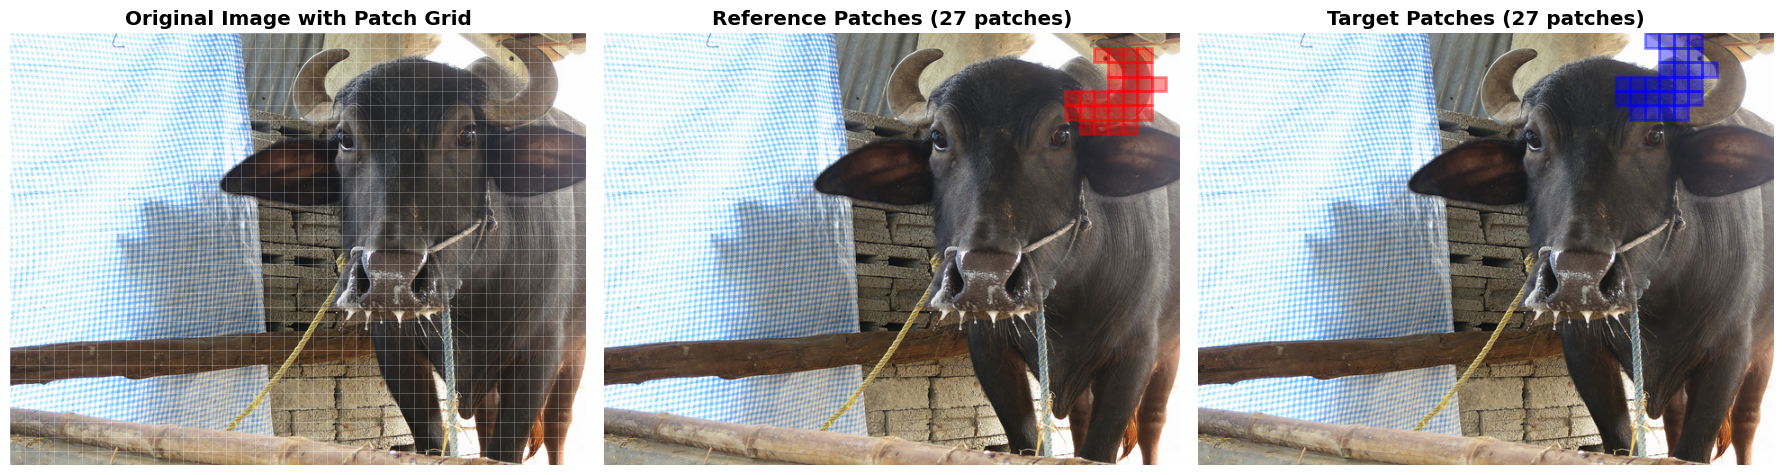

In [274]:
selected_dir = next(image_dirs)
metadata = load_metadata(selected_dir)
examine_data_structure(metadata)
visualize_patch_system(metadata)
artifact_type = list(metadata['artifacts'].keys())[0]
source_img = metadata['image_array']
reference_patch_indices = metadata['artifacts'][artifact_type]['patch_data']['reference_patch_indices']
target_patch_indices = metadata['artifacts'][artifact_type]['patch_data']['target_patch_indices']
caption = metadata['caption']

In [275]:
print(f"Loading data from: {selected_dir}")
print("=" * 60)

result_img = flux_gen.inject_artifacts(
    source_prompt=caption,
    target_prompt=caption,
    artifact_type=artifact_type,
    source_img=source_img,
    reference_patch_indices=reference_patch_indices,
    target_patch_indices=target_patch_indices,
    pe_step=0.0,
    inject_step=20,
)

Loading data from: ../exps/debug/addition/image_211956


Generating with seed 42:
Large brown cow tied up to a wooden post in a building. 
Done in 61.2s.


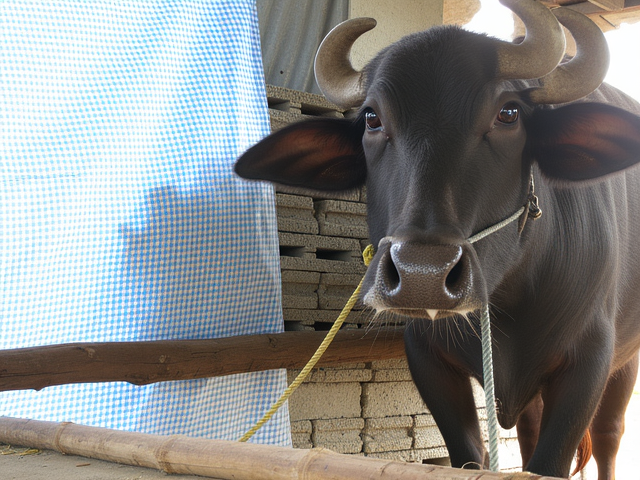

In [286]:
result_img

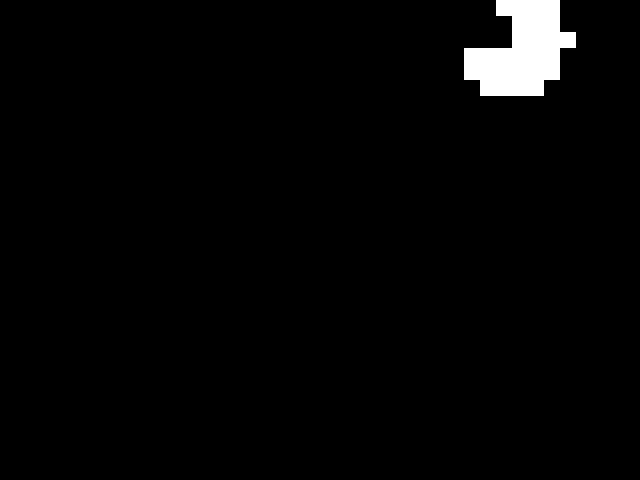

In [282]:
mask_array = np.array(metadata['artifacts'][artifact_type]['annotation']['target_mask'], dtype=np.uint8)*255
mask_image = Image.fromarray(mask_array)
mask_image.show()